In [16]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
data_path = tf.keras.utils.get_file(origin=url, extract=True,cache_dir=".", fname="data", cache_subdir=".")


In [13]:
data_path

'././data'

In [33]:
train_dir = Path(data_path)
train_dir

PosixPath('data')

In [44]:
test_path , train_path  = list(train_dir.glob("*/*/"))

In [46]:
test_path

PosixPath('data/aclImdb/test')

In [50]:
list(train_path.glob("*"))

[PosixPath('data/aclImdb/train/urls_unsup.txt'),
 PosixPath('data/aclImdb/train/neg'),
 PosixPath('data/aclImdb/train/urls_pos.txt'),
 PosixPath('data/aclImdb/train/urls_neg.txt'),
 PosixPath('data/aclImdb/train/pos'),
 PosixPath('data/aclImdb/train/unsupBow.feat'),
 PosixPath('data/aclImdb/train/labeledBow.feat')]

In [52]:
tf.__version__

'2.19.0'

In [140]:
seed = 42
raw_train_data = tf.keras.utils.text_dataset_from_directory(directory=train_path, batch_size=32, validation_split=0.2, subset="training", seed=seed)


Found 25000 files belonging to 2 classes.
Using 20000 files for training.


In [141]:
raw_valid_data =  tf.keras.utils.text_dataset_from_directory(directory=train_path, batch_size=32, validation_split=0.2, subset="validation", seed=seed)


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [142]:
raw_test_data = tf.keras.utils.text_dataset_from_directory(directory=test_path, batch_size=32)


Found 25000 files belonging to 2 classes.


### Preprocess the Data

In [88]:
import re
import string
text="<br />Hello <b>world</b>!"

def standarization(text):
    lower=tf.strings.lower(text)
    html=tf.strings.regex_replace(lower,"<.*?>","")
    stand_text = tf.strings.regex_replace(html,'[%s]'% re.escape(string.punctuation),'')
    return stand_text

In [90]:
vector_layer = tf.keras.layers.TextVectorization(standardize=standarization,
                                  max_tokens=20000,
                                  output_sequence_length=250
                                  )

In [143]:
train_text = raw_train_data.map(lambda x,y: x)


In [144]:
vector_layer.adapt(train_text)

In [171]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vector_layer(text), label

In [220]:
from tensorflow.keras import layers, losses
model = tf.keras.Sequential([
   layers.Embedding(20000, 16),
   layers.Dropout(0.5),
   layers.GlobalAveragePooling1D(),
   layers.Dropout(0.5),
   layers.Dense(1, activation='sigmoid') 
])


In [221]:
loss_fn = losses.BinaryCrossentropy()
metrics = tf.metrics.BinaryAccuracy(threshold=0.5)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss=loss_fn, optimizer=optimizer, metrics=[metrics])

In [222]:
train_ds = raw_train_data.map(vectorize_text)
val_ds = raw_valid_data.map(vectorize_text)
test_ds = raw_test_data.map(vectorize_text)

In [176]:
text_batch, label_batch = next(iter(train_ds))
text_batch

<tf.Tensor: shape=(32, 250), dtype=int64, numpy=
array([[  45,   23,  177, ...,    0,    0,    0],
       [  76,    1, 2696, ...,    1,   18, 1048],
       [  10,    7,   28, ...,    0,    0,    0],
       ...,
       [  11,  352,  653, ...,  214,    3, 3894],
       [  10,   17,    7, ...,    0,    0,    0],
       [  11,  194,   12, ...,    0,    0,    0]])>

In [195]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [182]:
next(iter(train_ds))

(<tf.Tensor: shape=(32, 250), dtype=int64, numpy=
 array([[2563,   13,    4, ...,  138,   26,  928],
        [ 677,   11,   37, ...,    3, 1273,   11],
        [6790,    7,  311, ...,  732,    8,    2],
        ...,
        [ 479, 1472,   32, ...,    3,  261,   11],
        [2535, 3337, 1240, ...,    0,    0,    0],
        [3635, 3947,    3, ...,   28,    5, 3947]])>,
 <tf.Tensor: shape=(32,), dtype=int32, numpy=
 array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0], dtype=int32)>)

In [223]:
history = model.fit(train_ds, validation_data=val_ds, epochs=25)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.5762 - loss: 0.6865 - val_binary_accuracy: 0.7402 - val_loss: 0.6484
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7225 - loss: 0.6284 - val_binary_accuracy: 0.7870 - val_loss: 0.5618
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.7825 - loss: 0.5381 - val_binary_accuracy: 0.8198 - val_loss: 0.4857
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8182 - loss: 0.4659 - val_binary_accuracy: 0.8362 - val_loss: 0.4309
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8428 - loss: 0.4153 - val_binary_accuracy: 0.8530 - val_loss: 0.3928
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8581 - loss: 0.3753 - val_binary_accuracy: 0.8528 - val_loss: 0.3694
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8698 - loss: 0.3466 - val_binary_accuracy: 0.8622 - val_loss: 0.3479
Epoch 

In [217]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - binary_accuracy: 0.8717 - loss: 0.3164
Loss:  0.3230249285697937
Accuracy:  0.8701599836349487


In [224]:
history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

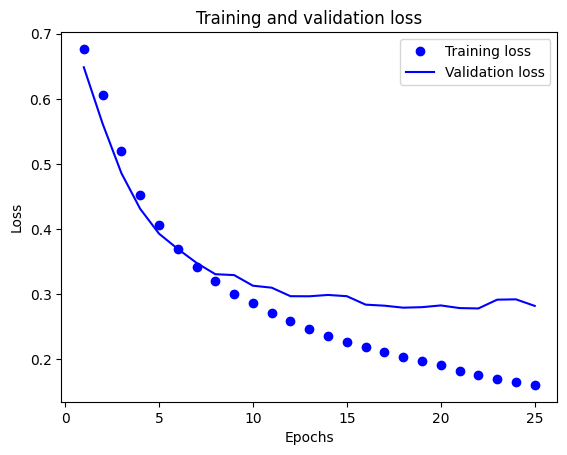

In [225]:
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

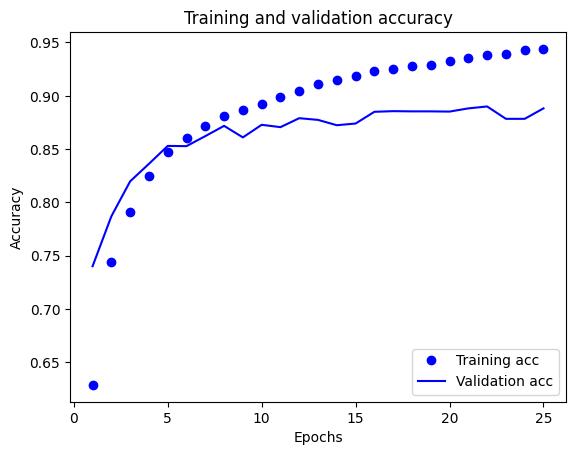

In [226]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In [229]:
export_model = tf.keras.Sequential([
  vector_layer,
  model,
  layers.Activation('sigmoid')
])

export_model.compile(
    loss=losses.BinaryCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
metrics = export_model.evaluate(raw_test_data, return_dict=True)
print(metrics)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5005 - loss: 0.5792
{'accuracy': 0.5006399750709534, 'loss': 0.579662561416626}


In [230]:
export_model = tf.keras.Sequential([
  vector_layer,
  model
])

export_model.compile(
    loss=losses.BinaryCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
metrics = export_model.evaluate(raw_test_data, return_dict=True)
print(metrics)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8669 - loss: 0.3206
{'accuracy': 0.8680800199508667, 'loss': 0.32633453607559204}


In [231]:
examples = tf.constant([
  "The movie was great!",
  "The movie was okay.",
  "The movie was terrible..."
])

export_model.predict(examples)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[0.53814524],
       [0.31365088],
       [0.2241132 ]], dtype=float32)